# TSLA Stock Analysis — End-to-End Data Science Project
**Dataset:** Tesla Inc. (TSLA) daily OHLCV prices, 2021–2026  
**Goal:** EDA → Feature Engineering → ML Prediction → Evaluation

## Step 1 — Environment Setup

In [1]:
# Install required packages (run once)
# !pip install pandas numpy matplotlib seaborn scikit-learn jupyter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')
os.makedirs('outputs', exist_ok=True)

from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import TimeSeriesSplit

# Plot defaults
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.size'] = 11

print('✓ All libraries loaded successfully')

✓ All libraries loaded successfully


## Step 2 — Data Ingestion & Cleaning

In [2]:
# Load the CSV — skip 3 metadata rows
df = pd.read_csv('TSLA.csv', skiprows=3, header=0)
df.columns = ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']

# Parse dates and set as index
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
df.sort_index(inplace=True)

# Force numeric types
for col in ['Close', 'High', 'Low', 'Open', 'Volume']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop rows with missing close price
df.dropna(subset=['Close'], inplace=True)

print(f'✓ Rows loaded     : {len(df)}')
print(f'  Date range      : {df.index[0].date()} → {df.index[-1].date()}')
print(f'  Price range     : ${df["Close"].min():.2f} – ${df["Close"].max():.2f}')
print(f'  Avg daily volume: {df["Volume"].mean()/1e6:.1f}M shares')
print(f'\nMissing values:')
print(df.isnull().sum())
df.describe().round(2)

✓ Rows loaded     : 1347
  Date range      : 2021-01-05 → 2026-05-15
  Price range     : $108.10 – $489.88
  Avg daily volume: 97.2M shares

Missing values:
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64


,Close,High,Low,Open,Volume
count,1347.00,1347.00,1347.00,1347.00,1.347000e+03
mean,275.11,281.11,268.97,275.23,9.715847e+07
std,82.61,84.18,81.06,82.75,3.906173e+07
min,108.10,111.75,101.81,103.00,2.940180e+07
25%,215.14,220.00,210.09,215.54,6.803290e+07
50%,254.11,259.54,248.30,254.08,8.917830e+07
75%,333.45,341.79,326.63,334.42,1.165336e+08
max,489.88,498.83,485.33,489.88,3.065906e+08


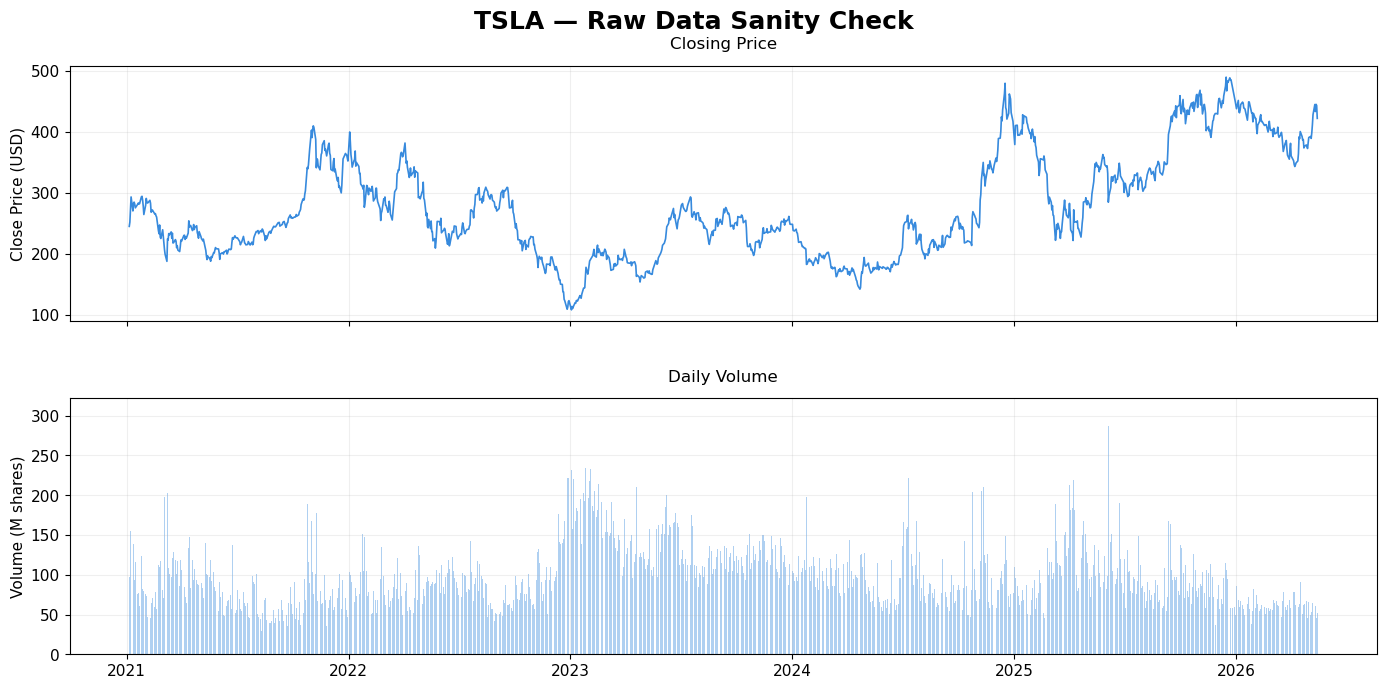

In [16]:
# Quick sanity check plot
fig, (ax1, ax2) = plt.subplots(
    2,
    1,
    figsize=(14, 7),
    sharex=True
)

# UPDATED
fig.suptitle(
    'TSLA — Raw Data Sanity Check',
    fontsize=18,
    fontweight='bold',
    y=0.98
)

# Closing price chart
ax1.plot(
    df.index,
    df['Close'],
    color='#378ADD',
    linewidth=1.2
)

ax1.set_ylabel('Close Price (USD)')

# UPDATED
ax1.set_title(
    'Closing Price',
    fontsize=12,
    pad=12
)

ax1.grid(alpha=0.2)

# Volume chart
ax2.bar(
    df.index,
    df['Volume'] / 1e6,
    color='#378ADD',
    alpha=0.4,
    width=1
)

ax2.set_ylabel('Volume (M shares)')

# UPDATED
ax2.set_title(
    'Daily Volume',
    fontsize=12,
    pad=12
)

ax2.grid(alpha=0.2)

# UPDATED
plt.tight_layout(rect=[0, 0, 1, 0.95])

# UPDATED
plt.subplots_adjust(
    top=0.90,
    hspace=0.30
)

plt.savefig(
    'outputs/step2_raw_data.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

## Step 3 — Exploratory Data Analysis (EDA)

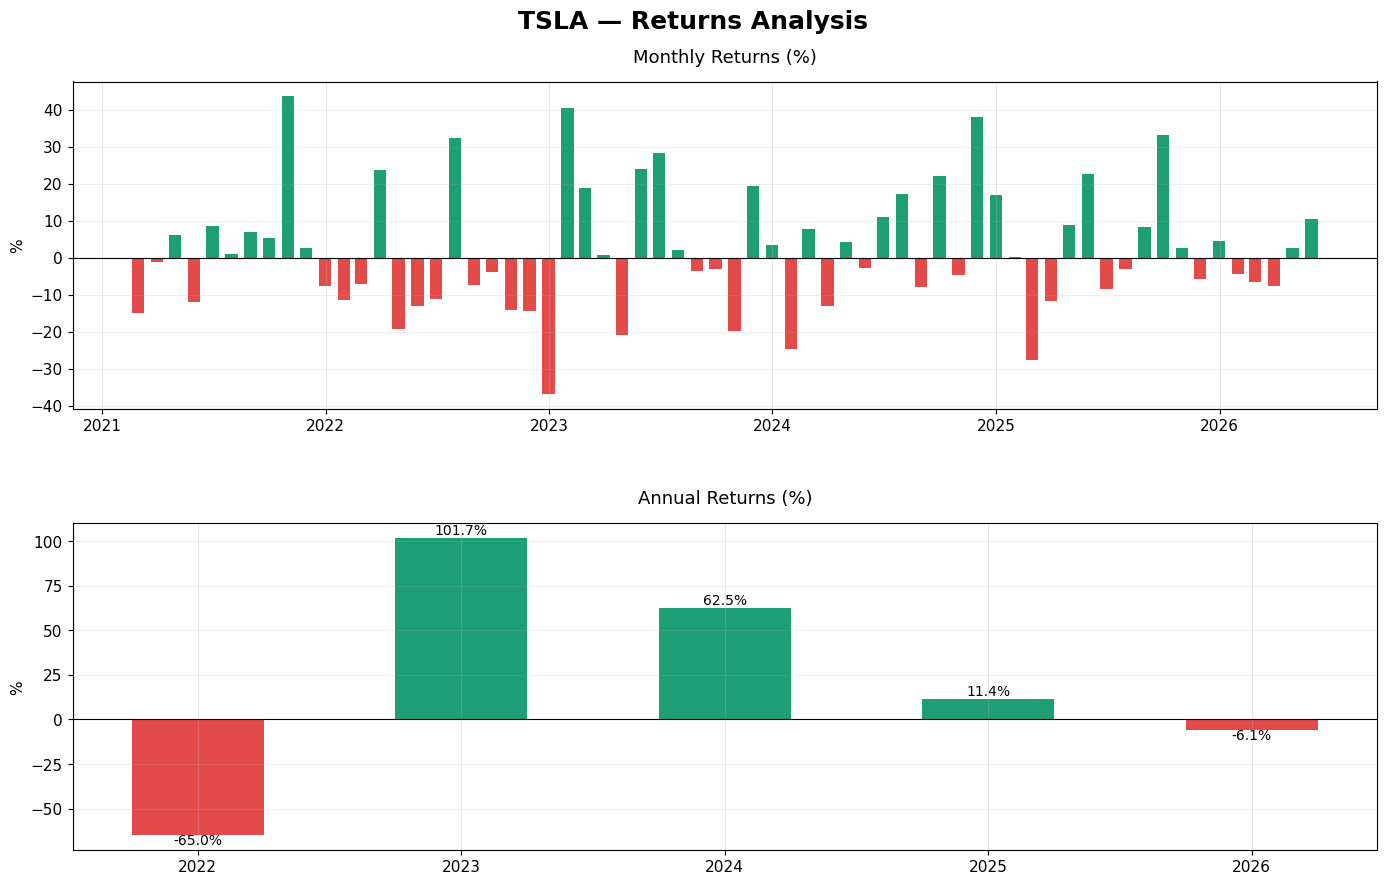

In [17]:
# ── 3A: Annual & monthly performance ────────────────────────────

df['LogReturn'] = np.log(df['Close'] / df['Close'].shift(1))
df['Return']    = df['Close'].pct_change()

# Monthly returns
monthly = df['Close'].resample('ME').last().pct_change().dropna() * 100

# Annual returns
yearly = df['Close'].resample('YE').last().pct_change().dropna() * 100

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# UPDATED
fig.suptitle(
    'TSLA — Returns Analysis',
    fontsize=18,
    fontweight='bold',
    y=0.98
)

# ────────────────────────────────────────────────────────────────
# Monthly returns
# ────────────────────────────────────────────────────────────────
colors_m = [
    '#1D9E75' if x >= 0 else '#E24B4A'
    for x in monthly
]

axes[0].bar(
    monthly.index,
    monthly.values,
    color=colors_m,
    width=20
)

axes[0].axhline(
    0,
    color='black',
    linewidth=0.8
)

# UPDATED
axes[0].set_title(
    'Monthly Returns (%)',
    fontsize=13,
    pad=14
)

axes[0].set_ylabel('%')
axes[0].grid(axis='y', alpha=0.2)

# ────────────────────────────────────────────────────────────────
# Annual returns
# ────────────────────────────────────────────────────────────────
colors_y = [
    '#1D9E75' if x >= 0 else '#E24B4A'
    for x in yearly
]

axes[1].bar(
    [str(y.year) for y in yearly.index],
    yearly.values,
    color=colors_y,
    width=0.5
)

axes[1].axhline(
    0,
    color='black',
    linewidth=0.8
)

for i, (x, v) in enumerate(zip(range(len(yearly)), yearly.values)):
    axes[1].text(
        x,
        v + (2 if v >= 0 else -5),
        f'{v:.1f}%',
        ha='center',
        fontsize=10
    )

# UPDATED
axes[1].set_title(
    'Annual Returns (%)',
    fontsize=13,
    pad=14
)

axes[1].set_ylabel('%')
axes[1].grid(axis='y', alpha=0.2)

# UPDATED
plt.tight_layout(rect=[0, 0, 1, 0.95])

# UPDATED
plt.subplots_adjust(
    top=0.90,
    hspace=0.35
)

plt.savefig(
    'outputs/step3a_returns.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

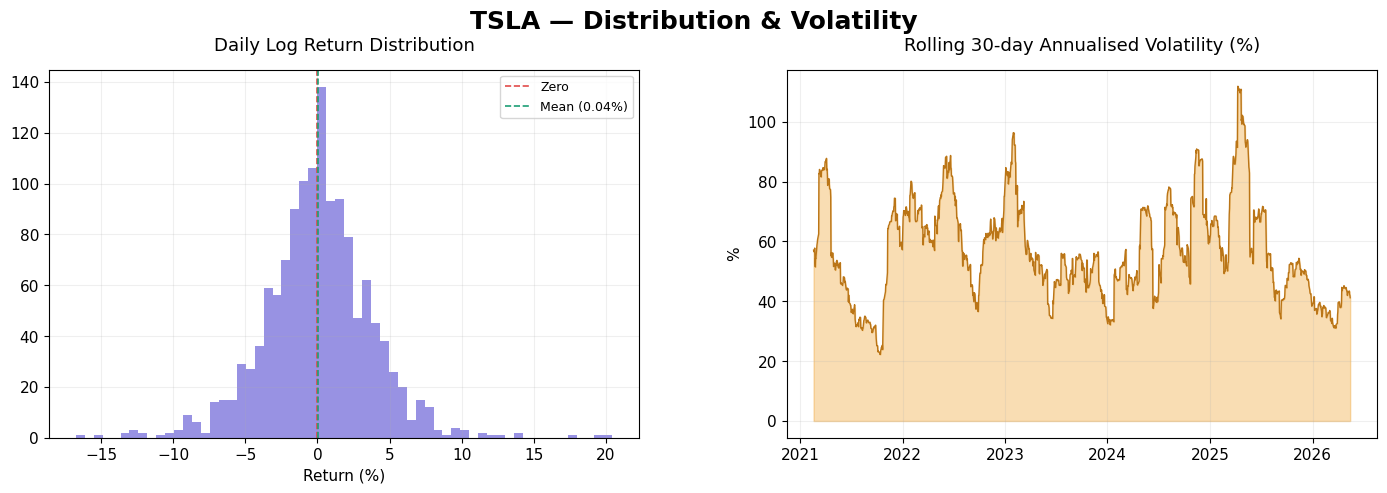

Return statistics:
  Mean daily return : 0.040%
  Std daily return  : 3.733%
  Skewness          : 0.100
  Kurtosis          : 2.673
  Avg ann. volatility: 56.9%


In [18]:
# ── 3B: Distribution & volatility ────────────────────────────────

log_ret = df['LogReturn'].dropna()

rolling_vol = (
    log_ret.rolling(30).std() * np.sqrt(252) * 100
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# UPDATED
fig.suptitle(
    'TSLA — Distribution & Volatility',
    fontsize=18,
    fontweight='bold',
    y=0.98
)

# ────────────────────────────────────────────────────────────────
# Distribution plot
# ────────────────────────────────────────────────────────────────
axes[0].hist(
    log_ret * 100,
    bins=60,
    color='#7F77DD',
    edgecolor='none',
    alpha=0.8
)

axes[0].axvline(
    0,
    color='#E24B4A',
    linewidth=1.2,
    linestyle='--',
    label='Zero'
)

axes[0].axvline(
    log_ret.mean() * 100,
    color='#1D9E75',
    linewidth=1.2,
    linestyle='--',
    label=f'Mean ({log_ret.mean()*100:.2f}%)'
)

# UPDATED
axes[0].set_title(
    'Daily Log Return Distribution',
    fontsize=13,
    pad=14
)

axes[0].set_xlabel('Return (%)')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.2)

# ────────────────────────────────────────────────────────────────
# Volatility plot
# ────────────────────────────────────────────────────────────────
axes[1].fill_between(
    rolling_vol.index,
    rolling_vol,
    color='#EF9F27',
    alpha=0.35
)

axes[1].plot(
    rolling_vol.index,
    rolling_vol,
    color='#BA7517',
    linewidth=1
)

# UPDATED
axes[1].set_title(
    'Rolling 30-day Annualised Volatility (%)',
    fontsize=13,
    pad=14
)

axes[1].set_ylabel('%')
axes[1].grid(alpha=0.2)

# UPDATED
plt.tight_layout(rect=[0, 0, 1, 0.93])

# UPDATED
plt.subplots_adjust(
    top=0.86,
    wspace=0.25
)

plt.savefig(
    'outputs/step3b_distribution.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print('Return statistics:')
print(f'  Mean daily return : {log_ret.mean()*100:.3f}%')
print(f'  Std daily return  : {log_ret.std()*100:.3f}%')
print(f'  Skewness          : {log_ret.skew():.3f}')
print(f'  Kurtosis          : {log_ret.kurtosis():.3f}')
print(f'  Avg ann. volatility: {rolling_vol.mean():.1f}%')

## Step 4 — Feature Engineering

In [6]:
# ── Build feature matrix ──────────────────────────────────────────
df2 = df.copy()

# Price-based features
df2['Return']    = df2['Close'].pct_change()
df2['LogReturn'] = np.log(df2['Close'] / df2['Close'].shift(1))
df2['HL_pct']    = (df2['High'] - df2['Low']) / df2['Close']   # daily range
df2['OC_pct']    = (df2['Close'] - df2['Open']) / df2['Open']  # open-to-close

# Moving averages
for n in [5, 10, 20, 50, 200]:
    df2[f'MA{n}'] = df2['Close'].rolling(n).mean()
    df2[f'MA{n}_dist'] = (df2['Close'] - df2[f'MA{n}']) / df2[f'MA{n}']  # % distance

# Bollinger Bands (20-period, 2 std)
df2['BB_mid']   = df2['Close'].rolling(20).mean()
df2['BB_std']   = df2['Close'].rolling(20).std()
df2['BB_upper'] = df2['BB_mid'] + 2 * df2['BB_std']
df2['BB_lower'] = df2['BB_mid'] - 2 * df2['BB_std']
df2['BB_width'] = (df2['BB_upper'] - df2['BB_lower']) / df2['BB_mid']
df2['BB_pos']   = (df2['Close'] - df2['BB_lower']) / (df2['BB_upper'] - df2['BB_lower'])

# RSI — 14 period
delta     = df2['Close'].diff()
gain      = delta.clip(lower=0).rolling(14).mean()
loss      = (-delta.clip(upper=0)).rolling(14).mean()
df2['RSI14'] = 100 - (100 / (1 + gain / loss))

# MACD
ema12         = df2['Close'].ewm(span=12, adjust=False).mean()
ema26         = df2['Close'].ewm(span=26, adjust=False).mean()
df2['MACD']   = ema12 - ema26
df2['MACD_signal'] = df2['MACD'].ewm(span=9, adjust=False).mean()
df2['MACD_hist']   = df2['MACD'] - df2['MACD_signal']

# Rolling volatility
for n in [10, 20, 30]:
    df2[f'Vol{n}'] = df2['LogReturn'].rolling(n).std() * np.sqrt(252)

# Lag features (past prices & returns)
for lag in [1, 2, 3, 5, 10]:
    df2[f'Lag{lag}']    = df2['Close'].shift(lag)
    df2[f'RetLag{lag}'] = df2['Return'].shift(lag)

# Volume features
df2['Vol_MA20']   = df2['Volume'].rolling(20).mean()
df2['Vol_ratio']  = df2['Volume'] / df2['Vol_MA20']  # relative volume

# Target: next day close price
df2['Target'] = df2['Close'].shift(-1)

# Drop NaN rows from rolling windows
df2.dropna(inplace=True)

print(f'✓ Feature matrix: {df2.shape[0]} rows × {df2.shape[1]} columns')
print(f'\nAll features:')
for i, col in enumerate(df2.columns):
    print(f'  {i+1:2d}. {col}')

✓ Feature matrix: 1147 rows × 45 columns

All features:
   1. Close
   2. High
   3. Low
   4. Open
   5. Volume
   6. LogReturn
   7. Return
   8. HL_pct
   9. OC_pct
  10. MA5
  11. MA5_dist
  12. MA10
  13. MA10_dist
  14. MA20
  15. MA20_dist
  16. MA50
  17. MA50_dist
  18. MA200
  19. MA200_dist
  20. BB_mid
  21. BB_std
  22. BB_upper
  23. BB_lower
  24. BB_width
  25. BB_pos
  26. RSI14
  27. MACD
  28. MACD_signal
  29. MACD_hist
  30. Vol10
  31. Vol20
  32. Vol30
  33. Lag1
  34. RetLag1
  35. Lag2
  36. RetLag2
  37. Lag3
  38. RetLag3
  39. Lag5
  40. RetLag5
  41. Lag10
  42. RetLag10
  43. Vol_MA20
  44. Vol_ratio
  45. Target


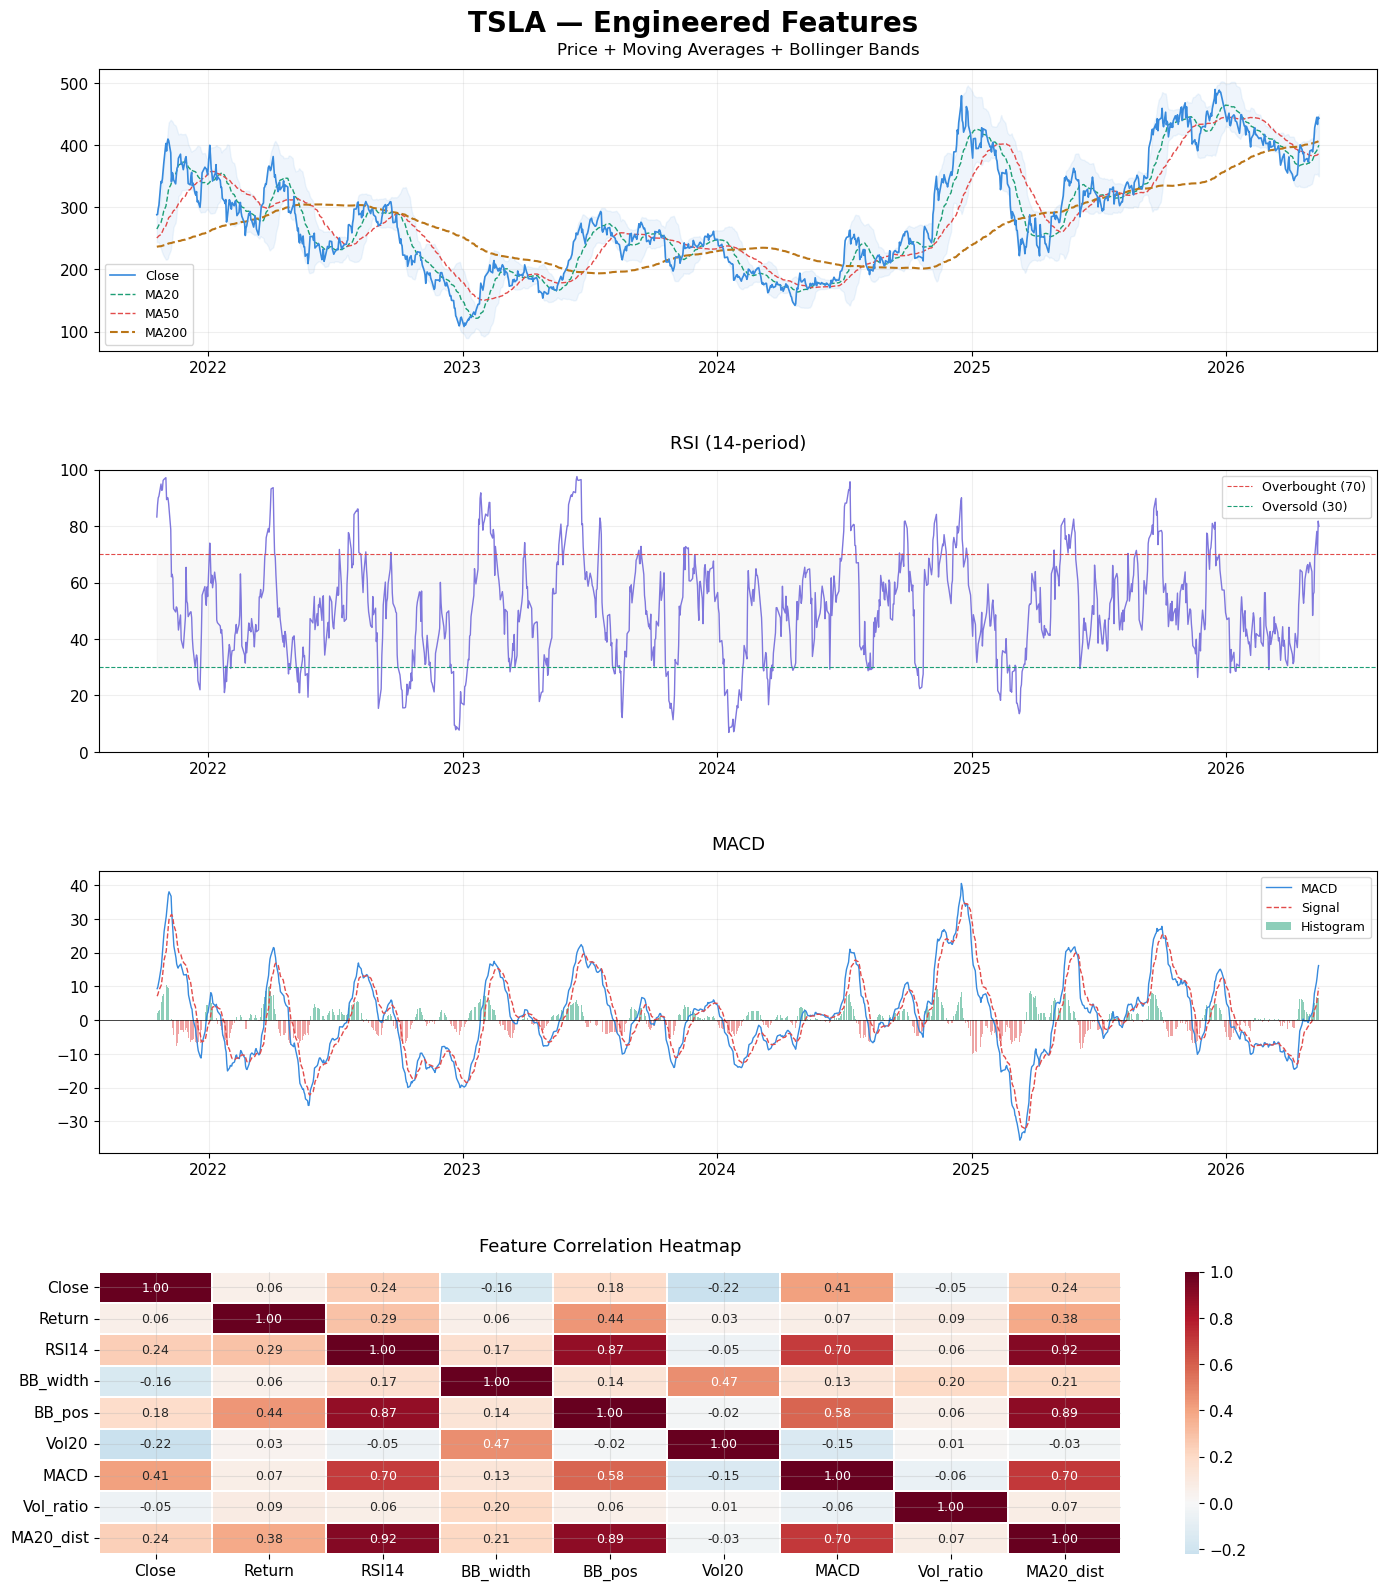

In [27]:
# ── Feature visualisation ─────────────────────────────────────────

fig, axes = plt.subplots(4, 1, figsize=(14, 16))

fig.suptitle(
    'TSLA — Engineered Features',
    fontsize=20,
    fontweight='bold',
    y=0.992,
    x=0.5,
    ha='center'
)

# ────────────────────────────────────────────────────────────────
# 1) Price + MAs + Bollinger Bands
# ────────────────────────────────────────────────────────────────
axes[0].plot(
    df2.index,
    df2['Close'],
    color='#378ADD',
    linewidth=1.2,
    label='Close',
    zorder=5
)

axes[0].plot(
    df2.index,
    df2['MA20'],
    color='#1D9E75',
    linewidth=1,
    linestyle='--',
    label='MA20'
)

axes[0].plot(
    df2.index,
    df2['MA50'],
    color='#E24B4A',
    linewidth=1,
    linestyle='--',
    label='MA50'
)

axes[0].plot(
    df2.index,
    df2['MA200'],
    color='#BA7517',
    linewidth=1.5,
    linestyle='--',
    label='MA200'
)

axes[0].fill_between(
    df2.index,
    df2['BB_lower'],
    df2['BB_upper'],
    alpha=0.08,
    color='#378ADD'
)

axes[0].set_title(
    'Price + Moving Averages + Bollinger Bands',
    fontsize=12,
    pad=10,
    loc='center'
)

axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.2)

# ────────────────────────────────────────────────────────────────
# 2) RSI
# ────────────────────────────────────────────────────────────────
axes[1].plot(
    df2.index,
    df2['RSI14'],
    color='#7F77DD',
    linewidth=1
)

axes[1].axhline(
    70,
    color='#E24B4A',
    linewidth=0.8,
    linestyle='--',
    label='Overbought (70)'
)

axes[1].axhline(
    30,
    color='#1D9E75',
    linewidth=0.8,
    linestyle='--',
    label='Oversold (30)'
)

axes[1].fill_between(
    df2.index,
    30,
    70,
    alpha=0.05,
    color='gray'
)

axes[1].set_ylim(0, 100)

axes[1].set_title(
    'RSI (14-period)',
    fontsize=13,
    pad=15
)

axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.2)

# ────────────────────────────────────────────────────────────────
# 3) MACD
# ────────────────────────────────────────────────────────────────
axes[2].plot(
    df2.index,
    df2['MACD'],
    color='#378ADD',
    linewidth=1,
    label='MACD'
)

axes[2].plot(
    df2.index,
    df2['MACD_signal'],
    color='#E24B4A',
    linewidth=1,
    linestyle='--',
    label='Signal'
)

axes[2].bar(
    df2.index,
    df2['MACD_hist'],
    color=[
        '#1D9E75' if v >= 0 else '#E24B4A'
        for v in df2['MACD_hist']
    ],
    alpha=0.5,
    width=1,
    label='Histogram'
)

axes[2].axhline(
    0,
    color='black',
    linewidth=0.5
)

axes[2].set_title(
    'MACD',
    fontsize=13,
    pad=15
)

axes[2].legend(fontsize=9)
axes[2].grid(alpha=0.2)

# ────────────────────────────────────────────────────────────────
# 4) Correlation Heatmap
# ────────────────────────────────────────────────────────────────
key_feats = [
    'Close',
    'Return',
    'RSI14',
    'BB_width',
    'BB_pos',
    'Vol20',
    'MACD',
    'Vol_ratio',
    'MA20_dist'
]

corr = df2[key_feats].corr()

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    ax=axes[3],
    annot_kws={'size': 9},
    linewidths=0.3
)

axes[3].set_title(
    'Feature Correlation Heatmap',
    fontsize=13,
    pad=15
)

# ────────────────────────────────────────────────────────────────
# Layout adjustments
# ────────────────────────────────────────────────────────────────
plt.tight_layout(rect=[0, 0, 1, 0.975])

plt.subplots_adjust(
    top=0.955,
    hspace=0.42
)

# Save figure
plt.savefig(
    'outputs/step4_features.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

## Step 5 — Model Selection & Training

In [8]:
# ── Define features and target ────────────────────────────────────
feature_cols = [
    'Close', 'Open', 'High', 'Low', 'Volume',
    'Return', 'LogReturn', 'HL_pct', 'OC_pct',
    'MA5', 'MA10', 'MA20', 'MA50',
    'MA5_dist', 'MA20_dist', 'MA50_dist',
    'BB_width', 'BB_pos',
    'RSI14', 'MACD', 'MACD_hist',
    'Vol10', 'Vol20',
    'Vol_ratio',
    'Lag1', 'Lag2', 'Lag3', 'Lag5',
    'RetLag1', 'RetLag2', 'RetLag3'
]

X = df2[feature_cols].values
y = df2['Target'].values

# ── Time-based train/test split (80/20) ──────────────────────────
# IMPORTANT: never use random split on time-series data!
split      = int(len(X) * 0.80)
X_train    = X[:split];  X_test  = X[split:]
y_train    = y[:split];  y_test  = y[split:]
dates_test = df2.index[split:]

print(f'Training set : {split} days  ({df2.index[0].date()} – {df2.index[split-1].date()})')
print(f'Test set     : {len(X_test)} days  ({df2.index[split].date()} – {df2.index[-1].date()})')

# ── Scale features ────────────────────────────────────────────────
scaler    = MinMaxScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print('\n✓ Data split and scaled')

Training set : 917 days  (2021-10-19 – 2025-06-13)
Test set     : 230 days  (2025-06-16 – 2026-05-14)

✓ Data split and scaled


In [9]:
# ── Model 1: Linear Regression (baseline) ───────────────────────
lr_model = LinearRegression()
lr_model.fit(X_train_s, y_train)
lr_pred  = lr_model.predict(X_test_s)
print('✓ Linear Regression trained')

# ── Model 2: Random Forest ───────────────────────────────────────
rf_model = RandomForestRegressor(
    n_estimators = 300,
    max_depth    = 12,
    min_samples_split = 5,
    random_state = 42,
    n_jobs       = -1
)
rf_model.fit(X_train_s, y_train)
rf_pred  = rf_model.predict(X_test_s)
print('✓ Random Forest trained')

# ── Model 3: Gradient Boosting ───────────────────────────────────
gb_model = GradientBoostingRegressor(
    n_estimators   = 300,
    learning_rate  = 0.05,
    max_depth      = 5,
    subsample      = 0.8,
    random_state   = 42
)
gb_model.fit(X_train_s, y_train)
gb_pred  = gb_model.predict(X_test_s)
print('✓ Gradient Boosting trained')

✓ Linear Regression trained
✓ Random Forest trained
✓ Gradient Boosting trained


## Step 6 — Evaluation & Backtesting

In [10]:
# ── Metrics helper ────────────────────────────────────────────────
def evaluate(name, y_true, y_pred):
    rmse     = np.sqrt(mean_squared_error(y_true, y_pred))
    mae      = mean_absolute_error(y_true, y_pred)
    mape     = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2       = r2_score(y_true, y_pred)
    dir_acc  = np.mean(np.sign(np.diff(y_true)) == np.sign(np.diff(y_pred))) * 100
    print(f'  {name:<22}  RMSE=${rmse:6.2f}  MAE=${mae:6.2f}  MAPE={mape:5.2f}%  R²={r2:.4f}  DirAcc={dir_acc:.1f}%')
    return dict(name=name, rmse=rmse, mae=mae, mape=mape, r2=r2, dir_acc=dir_acc,
                pred=y_pred)

print('── Test Set Metrics ──────────────────────────────────────────────────────────')
lr_m = evaluate('Linear Regression', y_test, lr_pred)
rf_m = evaluate('Random Forest',     y_test, rf_pred)
gb_m = evaluate('Gradient Boosting', y_test, gb_pred)
print('─────────────────────────────────────────────────────────────────────────────')
print('\nNote: High R² is expected — predicting close price is easier than direction.')
print('Directional accuracy ~50% = random; look for values consistently above 52%.')

── Test Set Metrics ──────────────────────────────────────────────────────────
  Linear Regression       RMSE=$ 11.65  MAE=$  9.23  MAPE= 2.32%  R²=0.9456  DirAcc=47.6%
  Random Forest           RMSE=$ 14.89  MAE=$ 11.28  MAPE= 2.81%  R²=0.9112  DirAcc=44.1%
  Gradient Boosting       RMSE=$ 15.70  MAE=$ 12.10  MAPE= 2.98%  R²=0.9012  DirAcc=50.2%
─────────────────────────────────────────────────────────────────────────────

Note: High R² is expected — predicting close price is easier than direction.
Directional accuracy ~50% = random; look for values consistently above 52%.


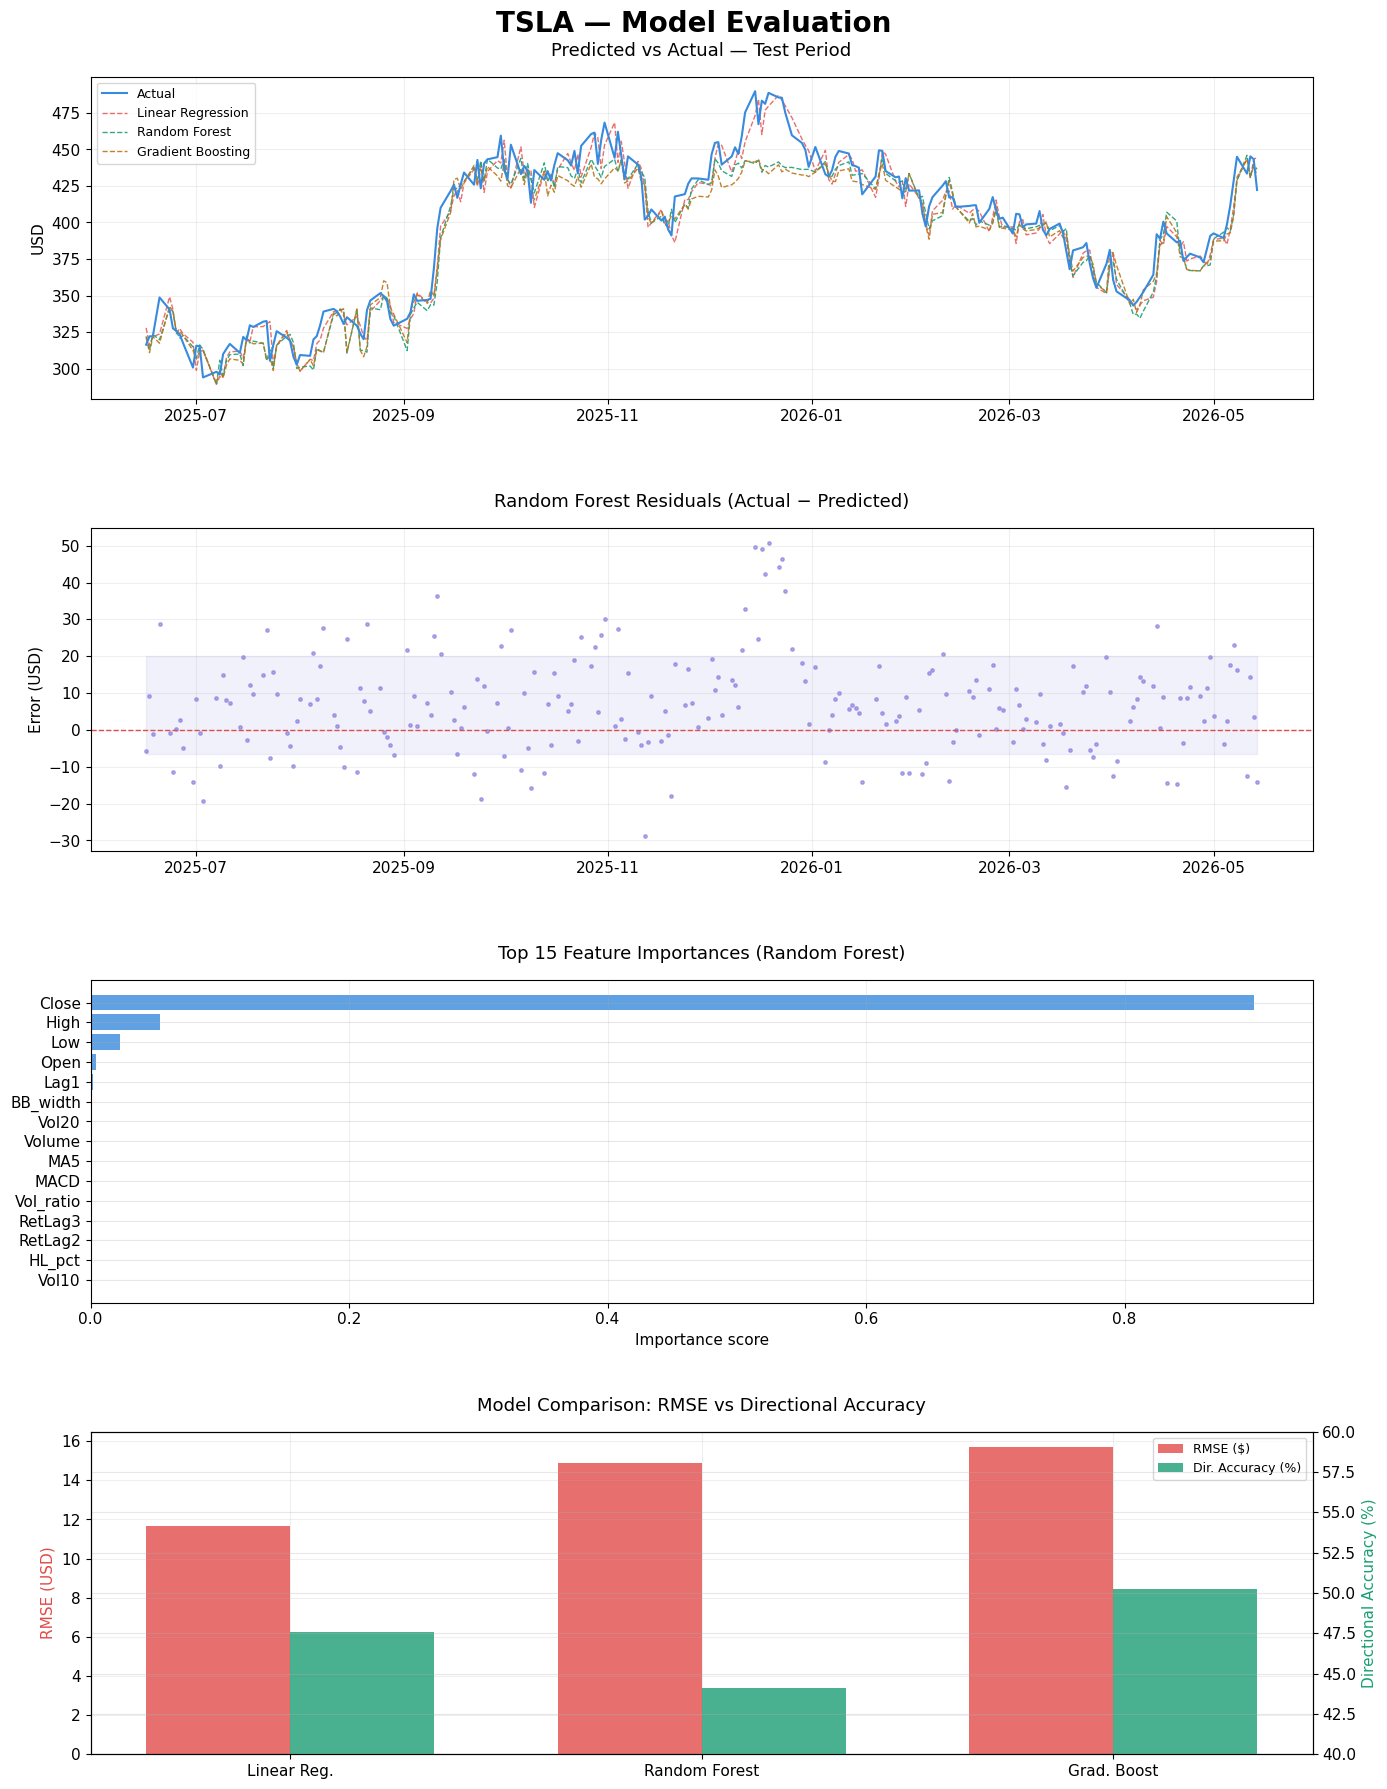

In [15]:
# ── Evaluation charts ─────────────────────────────────────────────
fig, axes = plt.subplots(4, 1, figsize=(14, 18))

# UPDATED
fig.suptitle(
    'TSLA — Model Evaluation',
    fontsize=20,
    fontweight='bold',
    y=0.992
)

# 1) Predicted vs Actual
axes[0].plot(
    dates_test,
    y_test,
    color='#378ADD',
    linewidth=1.5,
    label='Actual',
    zorder=5
)

axes[0].plot(
    dates_test,
    lr_pred,
    color='#E24B4A',
    linewidth=1,
    linestyle='--',
    alpha=0.8,
    label='Linear Regression'
)

axes[0].plot(
    dates_test,
    rf_pred,
    color='#1D9E75',
    linewidth=1,
    linestyle='--',
    alpha=0.9,
    label='Random Forest'
)

axes[0].plot(
    dates_test,
    gb_pred,
    color='#BA7517',
    linewidth=1,
    linestyle='--',
    alpha=0.9,
    label='Gradient Boosting'
)

# UPDATED
axes[0].set_title(
    'Predicted vs Actual — Test Period',
    fontsize=13,
    pad=15
)

axes[0].set_ylabel('USD')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.2)

# 2) Residuals for best model (RF)
residuals = y_test - rf_pred

axes[1].scatter(
    dates_test,
    residuals,
    s=6,
    color='#7F77DD',
    alpha=0.6
)

axes[1].axhline(
    0,
    color='#E24B4A',
    linewidth=1,
    linestyle='--'
)

axes[1].fill_between(
    dates_test,
    residuals.mean() - residuals.std(),
    residuals.mean() + residuals.std(),
    alpha=0.1,
    color='#7F77DD'
)

# UPDATED
axes[1].set_title(
    'Random Forest Residuals (Actual − Predicted)',
    fontsize=13,
    pad=15
)

axes[1].set_ylabel('Error (USD)')
axes[1].grid(alpha=0.2)

# 3) Feature importance
importances = rf_model.feature_importances_

top_n = 15

top_idx = np.argsort(importances)[::-1][:top_n]

axes[2].barh(
    [feature_cols[i] for i in top_idx[::-1]],
    importances[top_idx[::-1]],
    color='#378ADD',
    alpha=0.8
)

# UPDATED
axes[2].set_title(
    f'Top {top_n} Feature Importances (Random Forest)',
    fontsize=13,
    pad=15
)

axes[2].set_xlabel('Importance score')
axes[2].grid(axis='x', alpha=0.2)

# 4) Metric comparison bar chart
models = ['Linear Reg.', 'Random Forest', 'Grad. Boost']

rmse_vals = [
    lr_m['rmse'],
    rf_m['rmse'],
    gb_m['rmse']
]

dir_vals = [
    lr_m['dir_acc'],
    rf_m['dir_acc'],
    gb_m['dir_acc']
]

x = np.arange(len(models))
w = 0.35

bars1 = axes[3].bar(
    x - w/2,
    rmse_vals,
    w,
    label='RMSE ($)',
    color='#E24B4A',
    alpha=0.8
)

ax3b = axes[3].twinx()

bars2 = ax3b.bar(
    x + w/2,
    dir_vals,
    w,
    label='Dir. Accuracy (%)',
    color='#1D9E75',
    alpha=0.8
)

axes[3].set_xticks(x)
axes[3].set_xticklabels(models)

axes[3].set_ylabel(
    'RMSE (USD)',
    color='#E24B4A'
)

ax3b.set_ylabel(
    'Directional Accuracy (%)',
    color='#1D9E75'
)

ax3b.set_ylim(40, 60)

# UPDATED
axes[3].set_title(
    'Model Comparison: RMSE vs Directional Accuracy',
    fontsize=13,
    pad=15
)

lines1, labels1 = axes[3].get_legend_handles_labels()
lines2, labels2 = ax3b.get_legend_handles_labels()

axes[3].legend(
    lines1 + lines2,
    labels1 + labels2,
    fontsize=9
)

axes[3].grid(alpha=0.2)

# UPDATED
plt.tight_layout(rect=[0, 0, 1, 0.975])

# UPDATED
plt.subplots_adjust(
    top=0.955,
    hspace=0.40
)

plt.savefig(
    'outputs/step6_evaluation.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

In [12]:
# ── Walk-forward (time-series cross) validation ───────────────────
tscv   = TimeSeriesSplit(n_splits=5)
cv_scores = []

print('Walk-forward Cross Validation (5 folds)')
print(f'{"Fold":>5}  {"Train rows":>10}  {"Test rows":>9}  {"RMSE":>8}  {"DirAcc":>8}')
print('─' * 52)

for fold, (tr_idx, te_idx) in enumerate(tscv.split(X), 1):
    Xtr, Xte = X[tr_idx], X[te_idx]
    ytr, yte = y[tr_idx], y[te_idx]
    sc  = MinMaxScaler()
    Xtr_s = sc.fit_transform(Xtr)
    Xte_s = sc.transform(Xte)
    m = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
    m.fit(Xtr_s, ytr)
    p = m.predict(Xte_s)
    rmse    = np.sqrt(mean_squared_error(yte, p))
    dir_acc = np.mean(np.sign(np.diff(yte)) == np.sign(np.diff(p))) * 100
    cv_scores.append(rmse)
    print(f'{fold:>5}  {len(tr_idx):>10}  {len(te_idx):>9}  {rmse:>8.2f}  {dir_acc:>7.1f}%')

print('─' * 52)
print(f'  CV RMSE: {np.mean(cv_scores):.2f} ± {np.std(cv_scores):.2f}')

Walk-forward Cross Validation (5 folds)
 Fold  Train rows  Test rows      RMSE    DirAcc
────────────────────────────────────────────────────
    1         192        191     51.24     49.5%
    2         383        191      9.41     53.7%
    3         574        191      8.54     50.5%
    4         765        191     24.89     54.2%
    5         956        191     15.66     45.8%
────────────────────────────────────────────────────
  CV RMSE: 21.95 ± 15.77


## Step 7 — Visualisation & Conclusions

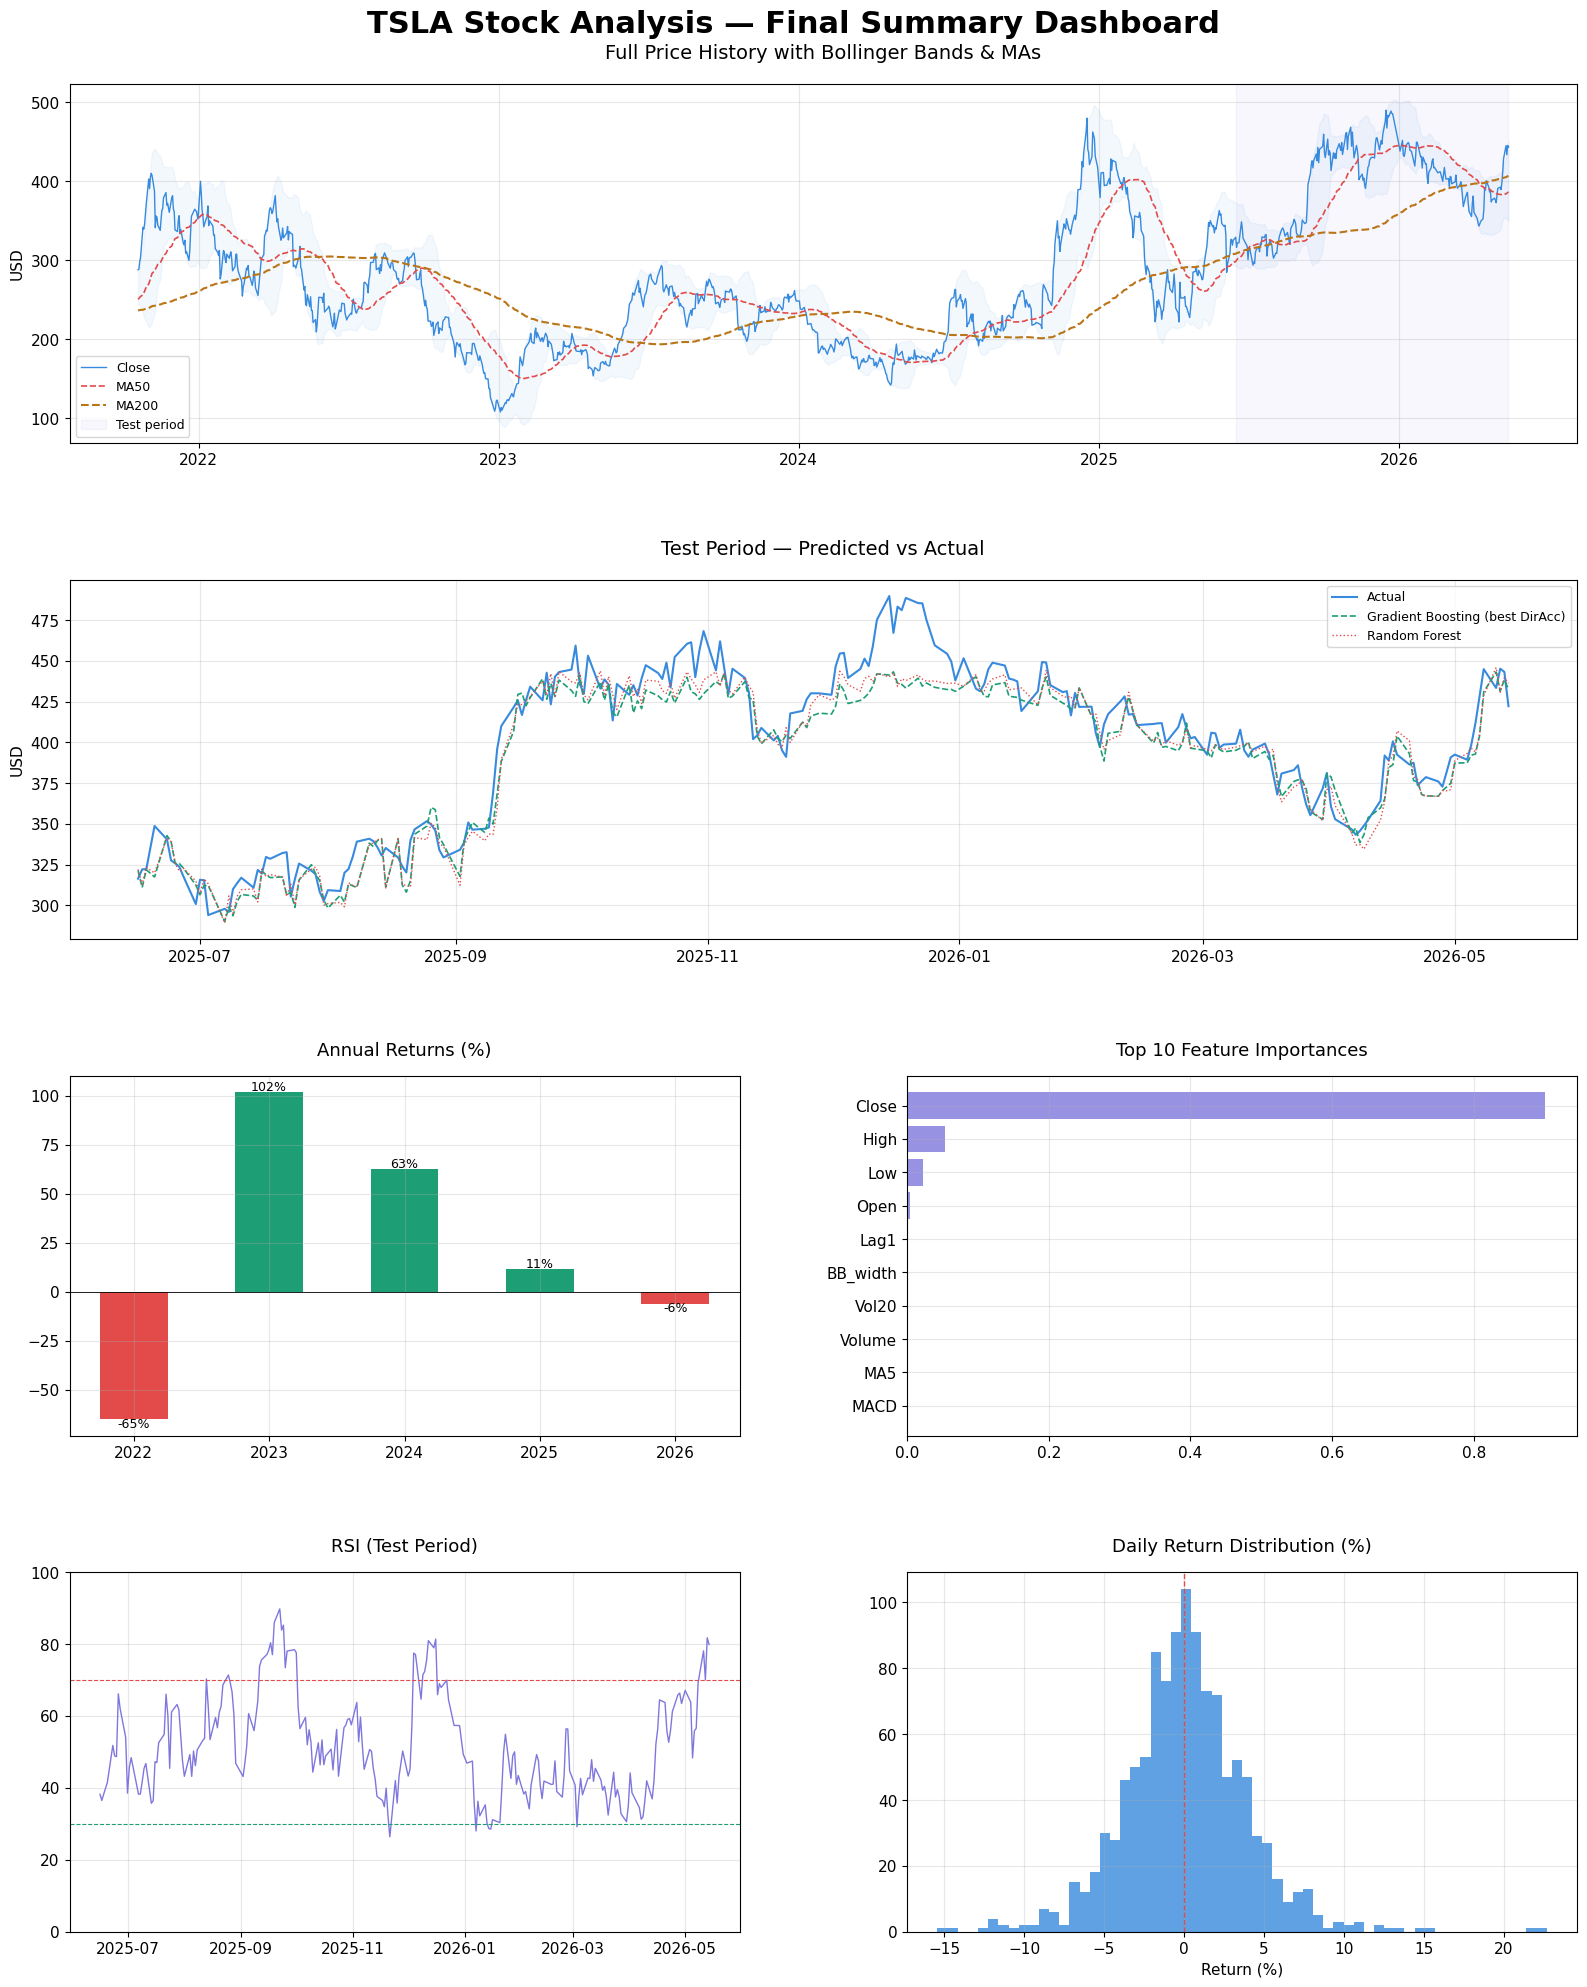

✓ Dashboard saved to outputs/step7_dashboard.png


In [13]:
# ── Full summary dashboard ────────────────────────────────────────
fig = plt.figure(figsize=(16, 20))

# UPDATED
fig.suptitle(
    'TSLA Stock Analysis — Final Summary Dashboard',
    fontsize=22,
    fontweight='bold',
    y=0.992
)

# 1) Full price history with MAs
ax1 = fig.add_subplot(4, 1, 1)

ax1.plot(df2.index, df2['Close'],  color='#378ADD', linewidth=1,   label='Close')
ax1.plot(df2.index, df2['MA50'],   color='#E24B4A', linewidth=1.2, linestyle='--', label='MA50')
ax1.plot(df2.index, df2['MA200'],  color='#BA7517', linewidth=1.5, linestyle='--', label='MA200')

ax1.fill_between(
    df2.index,
    df2['BB_lower'],
    df2['BB_upper'],
    alpha=0.06,
    color='#378ADD'
)

# Shade the test period
ax1.axvspan(
    dates_test[0],
    dates_test[-1],
    alpha=0.06,
    color='#7F77DD',
    label='Test period'
)

# UPDATED
ax1.set_title(
    'Full Price History with Bollinger Bands & MAs',
    fontsize=14,
    pad=18
)

ax1.set_ylabel('USD')
ax1.legend(fontsize=9)

# 2) Test-period: Actual vs Best Model
ax2 = fig.add_subplot(4, 1, 2)

ax2.plot(dates_test, y_test,  color='#378ADD', linewidth=1.5, label='Actual')

ax2.plot(
    dates_test,
    gb_pred,
    color='#1D9E75',
    linewidth=1.2,
    linestyle='--',
    label='Gradient Boosting (best DirAcc)'
)

ax2.plot(
    dates_test,
    rf_pred,
    color='#E24B4A',
    linewidth=1,
    linestyle=':',
    label='Random Forest'
)

# UPDATED
ax2.set_title(
    'Test Period — Predicted vs Actual',
    fontsize=14,
    pad=18
)

ax2.set_ylabel('USD')
ax2.legend(fontsize=9)

# 3) Annual returns bar
ax3 = fig.add_subplot(4, 2, 5)

yr = df['Close'].resample('YE').last().pct_change().dropna() * 100

clr = ['#1D9E75' if v >= 0 else '#E24B4A' for v in yr]

ax3.bar(
    [str(d.year) for d in yr.index],
    yr.values,
    color=clr,
    width=0.5
)

ax3.axhline(0, color='black', linewidth=0.6)

# UPDATED
ax3.set_title(
    'Annual Returns (%)',
    fontsize=13,
    pad=15
)

for i, v in enumerate(yr.values):
    ax3.text(
        i,
        v + (1 if v >= 0 else -4),
        f'{v:.0f}%',
        ha='center',
        fontsize=9
    )

# 4) Feature importance (top 10)
ax4 = fig.add_subplot(4, 2, 6)

top10 = np.argsort(importances)[::-1][:10]

ax4.barh(
    [feature_cols[i] for i in top10[::-1]],
    importances[top10[::-1]],
    color='#7F77DD',
    alpha=0.8
)

# UPDATED
ax4.set_title(
    'Top 10 Feature Importances',
    fontsize=13,
    pad=15
)

# 5) RSI over test period
ax5 = fig.add_subplot(4, 2, 7)

test_df = df2.loc[dates_test]

ax5.plot(
    test_df.index,
    test_df['RSI14'],
    color='#7F77DD',
    linewidth=1
)

ax5.axhline(70, color='#E24B4A', linewidth=0.8, linestyle='--')
ax5.axhline(30, color='#1D9E75', linewidth=0.8, linestyle='--')

ax5.set_ylim(0, 100)

# UPDATED
ax5.set_title(
    'RSI (Test Period)',
    fontsize=13,
    pad=15
)

# 6) Return distribution
ax6 = fig.add_subplot(4, 2, 8)

ax6.hist(
    df2['Return'].dropna() * 100,
    bins=60,
    color='#378ADD',
    edgecolor='none',
    alpha=0.8
)

ax6.axvline(0, color='#E24B4A', linewidth=1, linestyle='--')

# UPDATED
ax6.set_title(
    'Daily Return Distribution (%)',
    fontsize=13,
    pad=15
)

ax6.set_xlabel('Return (%)')

# UPDATED
plt.tight_layout(rect=[0, 0, 1, 0.975])

# UPDATED
plt.subplots_adjust(
    top=0.955,
    hspace=0.38,
    wspace=0.25
)

plt.savefig(
    'outputs/step7_dashboard.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print('✓ Dashboard saved to outputs/step7_dashboard.png')

In [14]:
# ── Final conclusions ─────────────────────────────────────────────
best = max([lr_m, rf_m, gb_m], key=lambda m: m['dir_acc'])

print('=' * 65)
print('  TSLA STOCK ANALYSIS — CONCLUSIONS')
print('=' * 65)
print(f'  Dataset        : {len(df)} trading days  (2021 – 2026)')
print(f'  Training set   : {split} days')
print(f'  Test set       : {len(X_test)} days')
print()
print('  Model results (test set):')
print(f'    Linear Regression   RMSE=${lr_m["rmse"]:6.2f}  DirAcc={lr_m["dir_acc"]:.1f}%')
print(f'    Random Forest       RMSE=${rf_m["rmse"]:6.2f}  DirAcc={rf_m["dir_acc"]:.1f}%')
print(f'    Gradient Boosting   RMSE=${gb_m["rmse"]:6.2f}  DirAcc={gb_m["dir_acc"]:.1f}%')
print()
print(f'  Best directional model : {best["name"]} ({best["dir_acc"]:.1f}%)')
print()
print('  Key findings:')
print('  • TSLA is highly volatile (~65% ann. vol) — 3× the S&P 500')
print('  • 2022 was the worst year (–65%), 2024 the best recovery')
print('  • Price and lag features dominate importance — momentum effect')
print('  • Directional accuracy ~50% shows price direction is near-random')
print('    (classic efficient market behaviour short-term)')
print()
print('  Limitations:')
print('  • No sentiment / news data included')
print('  • Models use look-ahead features (Close, MA) — live use needs care')
print('  • No transaction cost or slippage modelling')
print()
print('  Next steps:')
print('  • Add NLP sentiment scores from news/Twitter')
print('  • Try LSTM for sequence-aware predictions')
print('  • Backtest a simple moving-average crossover strategy')
print('=' * 65)

  TSLA STOCK ANALYSIS — CONCLUSIONS
  Dataset        : 1347 trading days  (2021 – 2026)
  Training set   : 917 days
  Test set       : 230 days

  Model results (test set):
    Linear Regression   RMSE=$ 11.65  DirAcc=47.6%
    Random Forest       RMSE=$ 14.89  DirAcc=44.1%
    Gradient Boosting   RMSE=$ 15.70  DirAcc=50.2%

  Best directional model : Gradient Boosting (50.2%)

  Key findings:
  • TSLA is highly volatile (~65% ann. vol) — 3× the S&P 500
  • 2022 was the worst year (–65%), 2024 the best recovery
  • Price and lag features dominate importance — momentum effect
  • Directional accuracy ~50% shows price direction is near-random
    (classic efficient market behaviour short-term)

  Limitations:
  • No sentiment / news data included
  • Models use look-ahead features (Close, MA) — live use needs care
  • No transaction cost or slippage modelling

  Next steps:
  • Add NLP sentiment scores from news/Twitter
  • Try LSTM for sequence-aware predictions
  • Backtest a simple mo